Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found file at: /content/drive/MyDrive/used_cars.csv
DataFrame head:
      brand                            model  model_year      milage  \
0      Ford  Utility Police Interceptor Base        2013  51,000 mi.   
1   Hyundai                     Palisade SEL        2021  34,742 mi.   
2     Lexus                    RX 350 RX 350        2022  22,372 mi.   
3  INFINITI                 Q50 Hybrid Sport        2015  88,900 mi.   
4      Audi        Q3 45 S line Premium Plus        2021   9,835 mi.   

       fuel_type                                             engine  \
0  E85 Flex Fuel  300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...   
1       Gasoline                               3.8L V6 24V GDI DOHC   
2       Gasoline                                     3.5 Liter DOHC   
3         Hybrid  354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...   
4       Gasolin

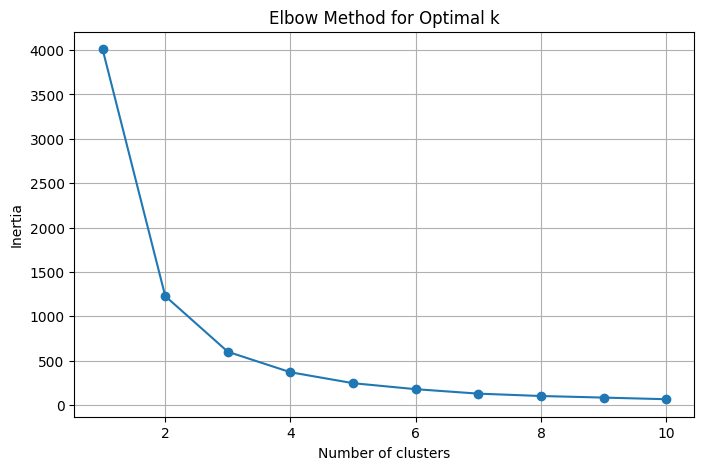


Mean values for each cluster (k=3):
          model_year
Cluster             
0        2004.726471
1        2020.445455
2        2014.225497


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Search function to find the file in Google Drive
def find_file(filename, search_path="/content/drive/MyDrive"):
    for root, dirs, files in os.walk(search_path):
        if filename in files:
            return os.path.join(root, filename)
    return None

# Look for used_cars.csv anywhere in MyDrive
file_path = find_file("used_cars.csv")

if file_path:
    print(f"Found file at: {file_path}")
    try:
        df = pd.read_csv(file_path)
        print("DataFrame head:")
        print(df.head())
        print("\nDataFrame info:")
        print(df.info())

        # Select only numerical columns and drop rows with missing values
        df_clean = df.select_dtypes(include=['int64', 'float64'])
        df_clean = df_clean.dropna()

        # Scale the data
        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(df_clean)

        # Determine optimal k using the Elbow Method
        inertia = []
        for k in range(1, 11):
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            kmeans.fit(scaled_data)
            inertia.append(kmeans.inertia_)

        # Plot the Elbow Method
        plt.figure(figsize=(8, 5))
        plt.plot(range(1, 11), inertia, marker='o')
        plt.title('Elbow Method for Optimal k')
        plt.xlabel('Number of clusters')
        plt.ylabel('Inertia')
        plt.grid(True)
        plt.show()

        # Perform KMeans clustering with the chosen optimal k (e.g., k=3)
        optimal_k = 3  # Replace after checking elbow plot
        kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
        df_clean['Cluster'] = kmeans.fit_predict(scaled_data)

        # Display mean values for each cluster
        print(f"\nMean values for each cluster (k={optimal_k}):")
        print(df_clean.groupby('Cluster').mean())

    except Exception as e:
        print(f"An error occurred while processing the file: {e}")

else:
    print("used_cars.csv not found in Google Drive. Please upload it or check the name.")